# Introduction
Artificial intelligence and machine learning are now commonly used in healthcare, particularly to support tasks such as disease screening, diagnosis, and risk prediction and stratification. These technologies can analyse large datasets far more quickly than a human clinician, which is especially valuable in healthcare systems already under significant pressure. In practice, this can help clinicians identify patterns that might otherwise be missed and support faster decision-making.

However, the use of AI in medical settings raises ethical concerns. Decisions made or influenced by algorithms raise important ethical questions, particularly around accountability, transparency, and patient trust. As AI systems become more embedded in clinical workflows, these issues become increasingly difficult to ignore.

A significant ethical challenge associated with medical AI is bias. Machine learning models are trained using historical data, and if that data contains inequalities or imbalances, the resulting models may reproduce those patterns. In a health care setting, this can lead to unequal performance across protected characteristics, such as error rates between gender, age and ethnicity. These disparities can contribute towards a higher rate of false negatives for certain populations, potentially delaying diagnosis and treatment. 



In [97]:
import datetime
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.express as px
import tensorflow as tf

# Modelling imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score, precision_score


In [98]:
data_frame = pd.read_csv('../data/thyroid_cancer_risk_data.csv')

display(data_frame.head())
print("Shape:", data_frame.shape)
print(data_frame.dtypes.to_frame("dtype"))

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


Shape: (212691, 17)
                       dtype
Patient_ID             int64
Age                    int64
Gender                   str
Country                  str
Ethnicity                str
Family_History           str
Radiation_Exposure       str
Iodine_Deficiency        str
Smoking                  str
Obesity                  str
Diabetes                 str
TSH_Level            float64
T3_Level             float64
T4_Level             float64
Nodule_Size          float64
Thyroid_Cancer_Risk      str
Diagnosis                str


In [99]:
missing_count = data_frame.isna().sum()
print("Missing values per column:")
print(missing_count)

duplicates = data_frame.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Missing values per column:
Patient_ID             0
Age                    0
Gender                 0
Country                0
Ethnicity              0
Family_History         0
Radiation_Exposure     0
Iodine_Deficiency      0
Smoking                0
Obesity                0
Diabetes               0
TSH_Level              0
T3_Level               0
T4_Level               0
Nodule_Size            0
Thyroid_Cancer_Risk    0
Diagnosis              0
dtype: int64
Number of duplicate rows: 0


In [100]:
# TUNABLE VARS
AGE_GROUPS = {
    "AGE_1": {"min": 0, "max": 29, "label": "0-29"},
    "AGE_2": {"min": 30, "max": 39, "label": "30-39"},
    "AGE_3": {"min": 40, "max": 49, "label": "40-49"},
    "AGE_4": {"min": 50, "max": 59, "label": "50-59"},
    "AGE_5": {"min": 60, "max": 69, "label": "60-69"},
    "AGE_6": {"min": 70, "max": 120, "label": "70+"},
}


In [101]:
# CONSTANTS
AGE_COL = "Age"
ETHNICITY_COL = "Ethnicity"
GENDER_COL = "Gender"
TARGET_COL = "Diagnosis"
POSITIVE_CLASS = "malignant"

In [102]:
df_copy = data_frame.copy()

# Patient_ID is removed because it is an identifier rather than a predictive or fairness-relevant feature.
df_copy = df_copy.drop(columns=["Patient_ID"])

# clean text cols
for column_name in df_copy.select_dtypes(include="object").columns:
    df_copy[column_name] = df_copy[column_name].str.strip().str.lower()

# binary target
df_copy["target"] = df_copy[TARGET_COL].map({"benign": 0, "malignant": 1})

print("Target distribution:")
print(df_copy["target"].value_counts())
print("\nTarget proportions:")
print(df_copy["target"].value_counts(normalize=True))

Target distribution:
target
0    163196
1     49495
Name: count, dtype: int64

Target proportions:
target
0    0.767292
1    0.232708
Name: proportion, dtype: float64


/tmp/ipykernel_853044/3071014677.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column_name in df_copy.select_dtypes(include="object").columns:


In [103]:
# Helper functions
def assign_age_group(age_value, age_groups):
    for group_key, group_info in age_groups.items():
        if group_info["min"] <= age_value <= group_info["max"]:
            return group_info["label"]
    return "unknown"

def plot_heatmap(data_frame, title, x_label, y_label, colorbar_label="Value", decimal_places=2):
    plt.figure(figsize=(10, 6))
    plt.imshow(data_frame, aspect="auto")
    plt.colorbar(label=colorbar_label)
    plt.xticks(ticks=range(len(data_frame.columns)), labels=data_frame.columns, rotation=45)
    plt.yticks(ticks=range(len(data_frame.index)), labels=data_frame.index)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    for row_index in range(data_frame.shape[0]):
        for column_index in range(data_frame.shape[1]):
            plt.text(
                column_index,
                row_index,
                f"{data_frame.iloc[row_index, column_index]:.{decimal_places}f}",
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()


def calculate_group_metrics(true_values, predicted_values):
    """
    Calculate classification and fairness-related metrics for a subgroup.

    This function evaluates model performance for a specific subgroup by
    comparing the true labels with the predicted labels. It returns standard
    classification metrics alongside fairness-relevant measures that are
    particularly important in medical prediction tasks, such as the false
    negative rate and specificity.

    Parameters
    ----------
    true_values : array-like
        The true binary class labels for the subgroup.
        Expected values are 0 for benign and 1 for malignant.

    predicted_values : array-like
        The predicted binary class labels for the subgroup.
        Expected values are 0 for benign and 1 for malignant.

    Returns
    -------
    dict
        A dictionary containing:
        - accuracy : Overall proportion of correct predictions
        - precision : Proportion of predicted positive cases that were correct
        - recall : Proportion of actual positive cases correctly identified
        - f1_score : Harmonic mean of precision and recall
        - false_negative_rate : Proportion of positive cases incorrectly predicted as negative
        - specificity : Proportion of actual negative cases correctly identified
        - true_negative : Number of true negative predictions
        - false_positive : Number of false positive predictions
        - false_negative : Number of false negative predictions
        - true_positive : Number of true positive predictions

    Notes
    -----
    This function is useful for subgroup fairness analysis because it helps
    identify whether model performance differs across protected characteristics
    such as ethnicity, gender, or age group. In a medical context, the false
    negative rate is especially important, as high false negatives may indicate
    missed diagnoses in particular subgroups.
    """
    confusion_values = confusion_matrix(true_values, predicted_values, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = confusion_values.ravel()

    accuracy = accuracy_score(true_values, predicted_values)
    precision = precision_score(true_values, predicted_values, zero_division=0)
    recall = recall_score(true_values, predicted_values, zero_division=0)
    f1 = f1_score(true_values, predicted_values, zero_division=0)

    false_negative_rate = (false_negative / (false_negative + true_positive)
        if (false_negative + true_positive) > 0 else 0
    )

    specificity = (true_negative / (true_negative + false_positive) 
        if (true_negative + false_positive) > 0 else 0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "false_negative_rate": false_negative_rate,
        "specificity": specificity,
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_positive": true_positive
    }

In [104]:
# create age group column
df_copy["Age_Group"] = df_copy[AGE_COL].apply(
    assign_age_group,
    age_groups=AGE_GROUPS
)

age_group_order = [group_info["label"] for group_info in AGE_GROUPS.values()]
age_group_counts = df_copy["Age_Group"].value_counts().reindex(age_group_order, fill_value=0)

print("Age group distribution:")
print(age_group_counts)

Age group distribution:
Age_Group
0-29     42657
30-39    28506
40-49    28361
50-59    28494
60-69    28055
70+      56618
Name: count, dtype: int64


# Subgroup analysis of target prevalence

To explore potential fairness concerns within the dataset, the proportion of malignant diagnoses was examined across gender, age group, and ethnicity. The results indicate that malignant diagnosis prevalence is broadly stable across gender and age categories. Female participants had a malignant diagnosis rate of 23.32%, compared with 23.20% for males. Similarly, across all defined age groups, the malignant rate remained highly consistent, fluctuating only minimally between 23.02% and 23.39%.

In contrast, substantial variation was observed across ethnicity. The Asian subgroup exhibited the highest malignant diagnosis rate at 33.46%, followed by the African subgroup at 25.47%. Lower rates were observed among Middle Eastern (17.93%), Caucasian (17.85%), and Hispanic (17.74%) participants. This suggests that ethnicity is associated with a considerably greater difference in target prevalence than either gender or age.

This pattern is important from both a modelling and ethical perspective. Where a target label is distributed unevenly across demographic groups, predictive models may learn strong group-dependent associations. Such behaviour may improve apparent predictive accuracy while simultaneously increasing the risk of unfair or overly demographic-dependent decision making. Consequently, ethnicity should be treated as a key variable in subsequent fairness evaluation, particularly when assessing subgroup recall, false negative rates, and calibration.

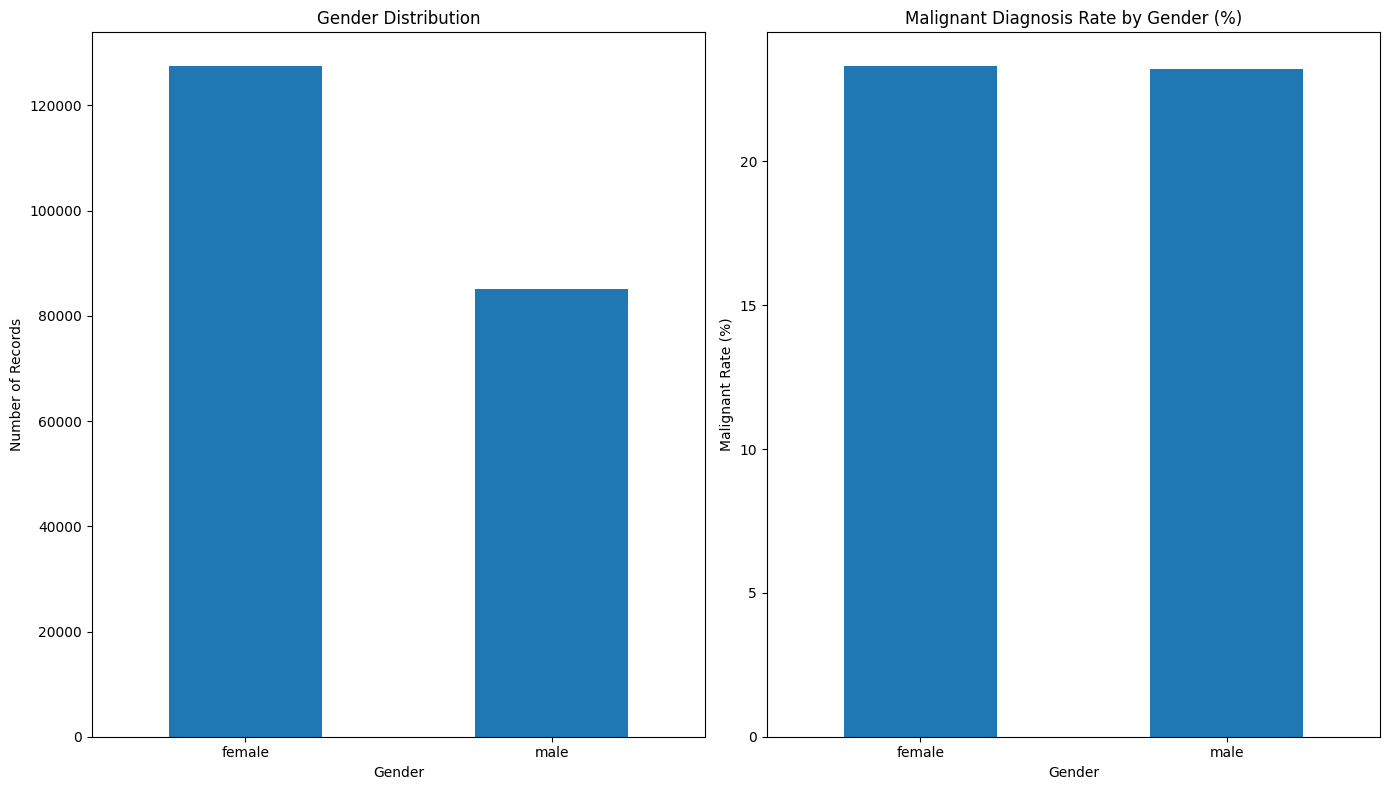

In [105]:
gender_counts = df_copy[GENDER_COL].value_counts().sort_index()
gender_malignant_rate = df_copy.groupby(GENDER_COL)["target"].mean().sort_index() * 100

figure, axes = plt.subplots(1, 2, figsize=(14, 8))

gender_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Gender Distribution")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Number of Records")
axes[0].tick_params(axis="x", rotation=0)

gender_malignant_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Malignant Diagnosis Rate by Gender (%)")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Malignant Rate (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()



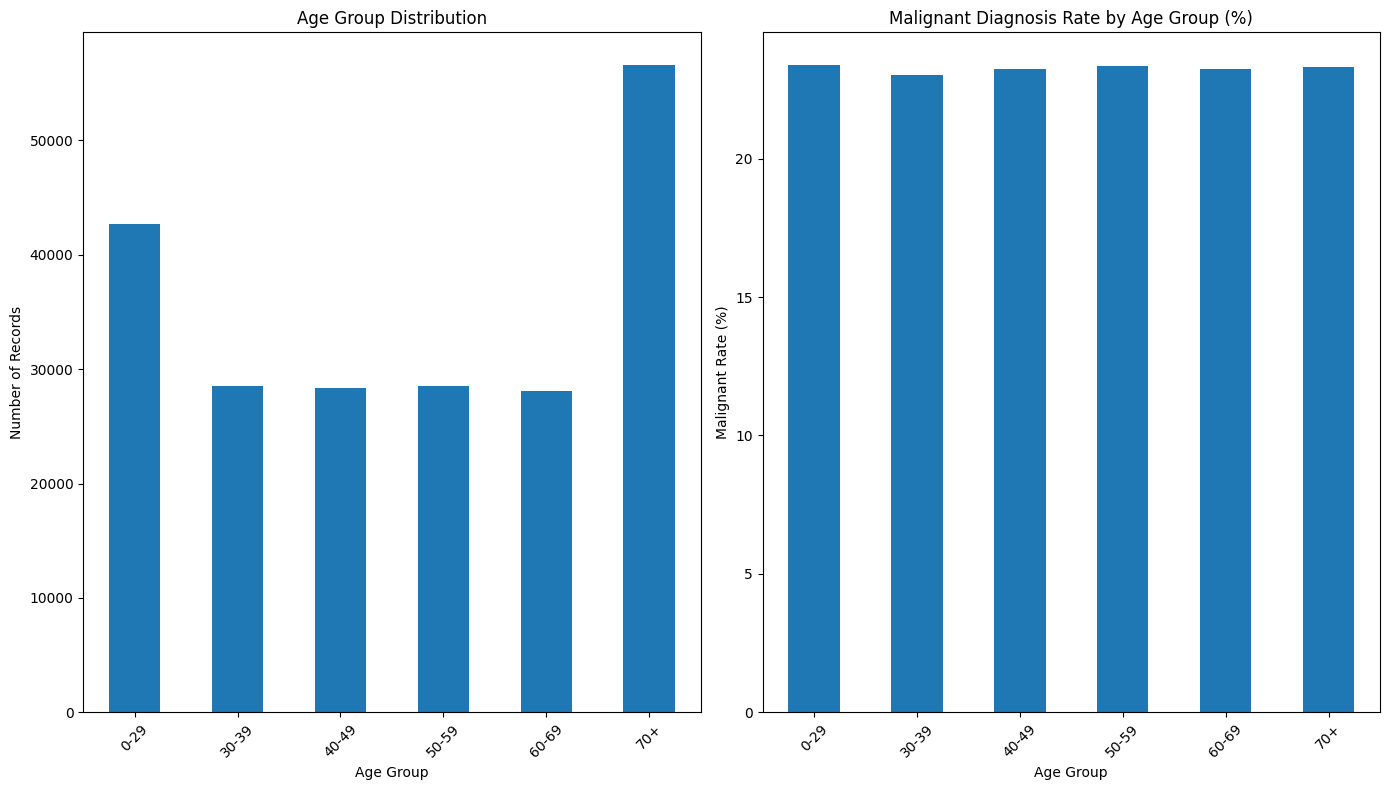

In [106]:
age_group_order = [group_info["label"] for group_info in AGE_GROUPS.values()]

age_group_counts = df_copy["Age_Group"].value_counts().reindex(age_group_order, fill_value=0)
age_group_malignant_rate = (
    df_copy.groupby("Age_Group")["target"].mean().reindex(age_group_order, fill_value=0) * 100
)

figures, axes = plt.subplots(1, 2, figsize=(14, 8))

age_group_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Age Group Distribution")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Records")
axes[0].tick_params(axis="x", rotation=45)

age_group_malignant_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Malignant Diagnosis Rate by Age Group (%)")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Malignant Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

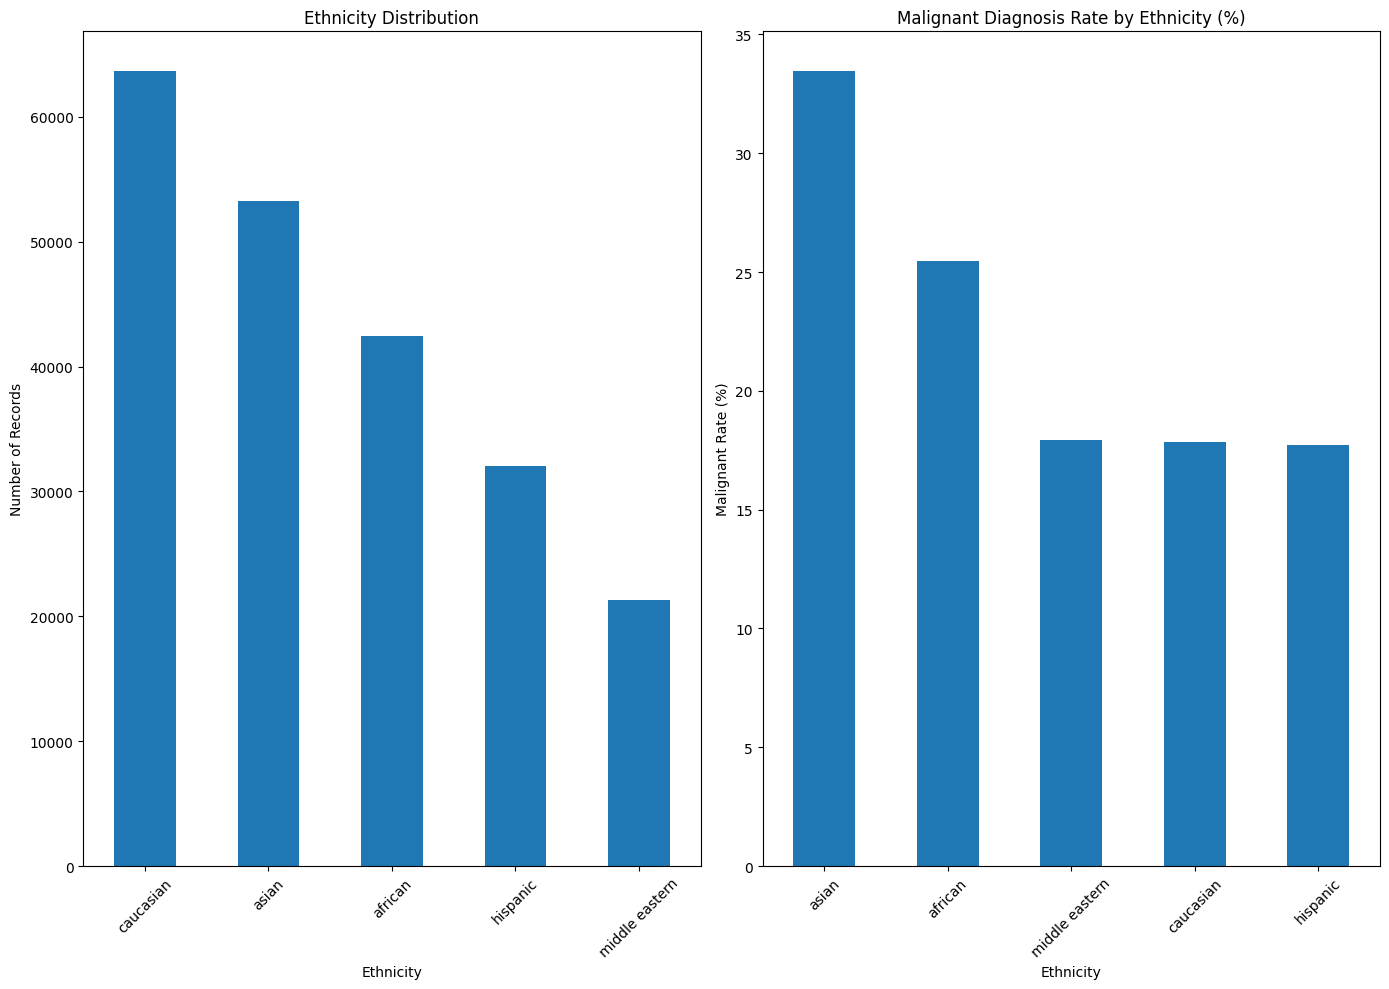

In [107]:
ethnicity_counts = df_copy[ETHNICITY_COL].value_counts().sort_values(ascending=False)
ethnicity_malignant_rate = (
    df_copy.groupby(ETHNICITY_COL)["target"].mean().sort_values(ascending=False) * 100
)

figure, axes = plt.subplots(1, 2, figsize=(14, 10))

ethnicity_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Ethnicity Distribution")
axes[0].set_xlabel("Ethnicity")
axes[0].set_ylabel("Number of Records")
axes[0].tick_params(axis="x", rotation=45)

ethnicity_malignant_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Malignant Diagnosis Rate by Ethnicity (%)")
axes[1].set_xlabel("Ethnicity")
axes[1].set_ylabel("Malignant Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [108]:
gender_ethnicity_counts = pd.crosstab(df_copy[GENDER_COL], df_copy[ETHNICITY_COL])
print(gender_ethnicity_counts)

gender_age_counts = pd.crosstab(df_copy[GENDER_COL], df_copy["Age_Group"])
print("Gender x Age Group counts:")
print(gender_age_counts)

gender_ethnicity_malignant_rate = pd.crosstab(df_copy[GENDER_COL], df_copy[ETHNICITY_COL], values=df_copy["target"], aggfunc="mean") * 100
print(gender_ethnicity_malignant_rate)

gender_age_malignant_rate = pd.crosstab(df_copy[GENDER_COL], df_copy["Age_Group"], values=df_copy["target"], aggfunc="mean") * 100
print("Gender x Age Group malignant rate (%):")
print(gender_age_malignant_rate)

Ethnicity  african  asian  caucasian  hispanic  middle eastern
Gender                                                        
female       25519  31958      38035     19230           12785
male         16895  21303      25634     12782            8550
Gender x Age Group counts:
Age_Group   0-29  30-39  40-49  50-59  60-69    70+
Gender                                             
female     25533  17097  16994  17168  16844  33891
male       17124  11409  11367  11326  11211  22727
Ethnicity    african      asian  caucasian   hispanic  middle eastern
Gender                                                               
female     25.475136  33.700482  17.780991  17.763911       17.911615
male       25.469074  33.093930  17.956620  17.704585       17.964912
Gender x Age Group malignant rate (%):
Age_Group       0-29      30-39      40-49      50-59      60-69        70+
Gender                                                                     
female     23.279677  23.144411  23.520066

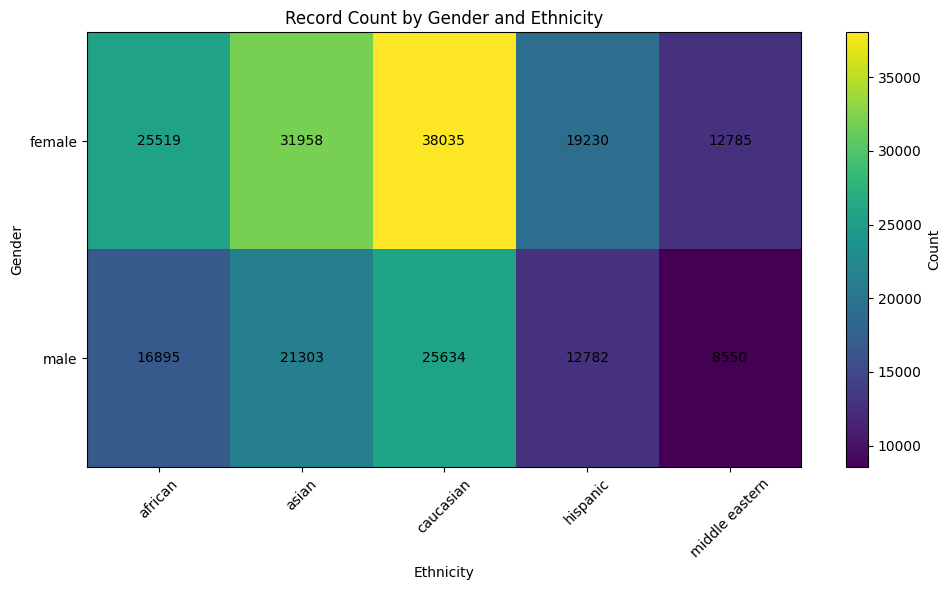

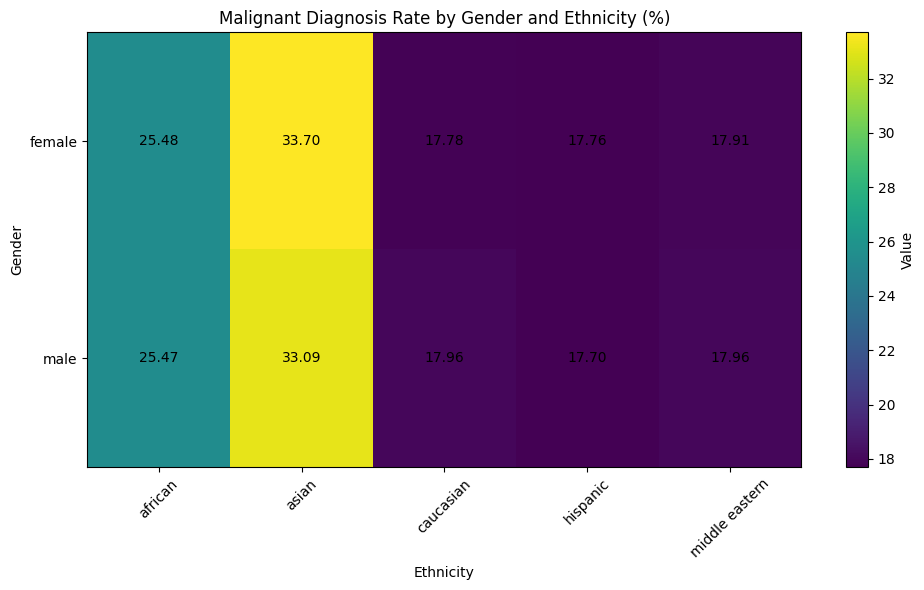

In [109]:
plot_heatmap(
    gender_ethnicity_counts,
    title="Record Count by Gender and Ethnicity",
    x_label="Ethnicity",
    y_label="Gender",
    colorbar_label="Count",
    decimal_places=0
)

plot_heatmap(
    gender_ethnicity_malignant_rate,
    title="Malignant Diagnosis Rate by Gender and Ethnicity (%)",
    x_label="Ethnicity",
    y_label="Gender",
    decimal_places=2
)

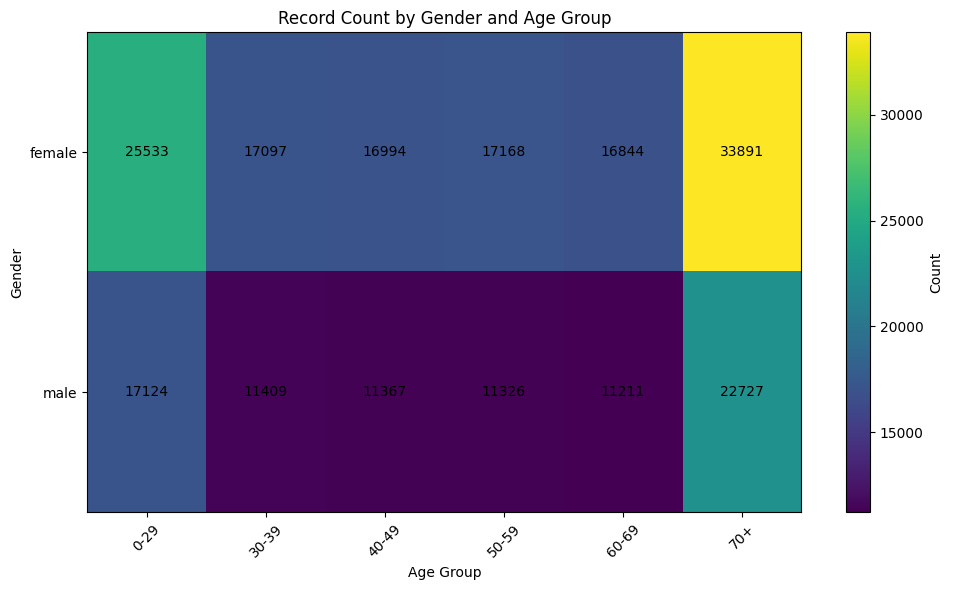

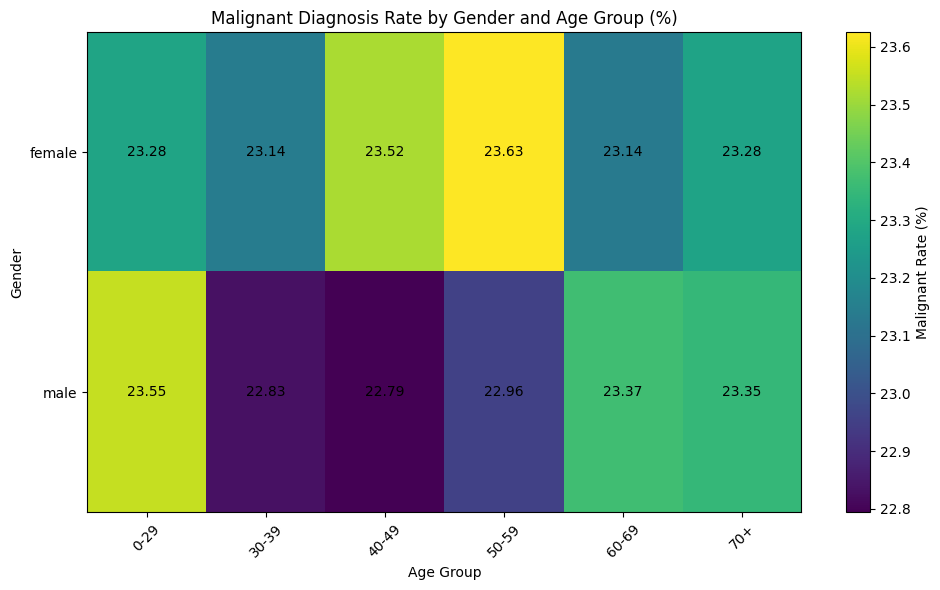

In [110]:
plot_heatmap(
    gender_age_counts,
    title="Record Count by Gender and Age Group",
    x_label="Age Group",
    y_label="Gender",
    colorbar_label="Count",
    decimal_places=0
)

plot_heatmap(
    gender_age_malignant_rate,
    title="Malignant Diagnosis Rate by Gender and Age Group (%)",
    x_label="Age Group",
    y_label="Gender",
    colorbar_label="Malignant Rate (%)",
    decimal_places=2
)

# Intersectional subgroup analysis

To extend the initial subgroup audit, an intersectional analysis was conducted across gender and ethnicity, and across gender and age group. This was undertaken to determine whether disparities that appeared modest at the single-group level became more pronounced when demographic characteristics were considered jointly.

The results indicate that, although the dataset contains more female than male records, the prevalence of malignant diagnosis is highly consistent between genders within each ethnicity group. For example, the malignant rate among African participants was 25.48% for females and 25.47% for males, while the corresponding rates among Asian participants were 33.70% and 33.09%. Similar consistency was observed for Caucasian, Hispanic, and Middle Eastern groups, all of which showed only minor differences between male and female participants.

A similarly stable pattern was observed across gender and age groups. Malignant diagnosis prevalence remained close to 23% across all age categories for both male and female participants, with only very small fluctuations. This suggests that age-group-related variation in the target label is limited when age is grouped in the current manner.

In contrast, ethnicity remains the most prominent source of variation in target prevalence. The Asian subgroup exhibits a substantially higher malignant diagnosis rate than all other ethnic groups, and this pattern is present in both females and males. This indicates that the observed ethnicity-based difference is not explained by gender composition alone. From a fairness perspective, this is important because a predictive model may learn strong ethnicity-dependent associations, which could influence model behaviour across demographic groups.

Overall, the intersectional analysis suggests that the principal source of demographic variation in the target variable is ethnicity rather than gender or age group. Consequently, ethnicity should be prioritised in subsequent fairness evaluation, particularly when assessing subgroup recall, false negative rate, and calibration.

### Selection of Ethnicity for Further Fairness Analysis

Following the initial subgroup and intersectional analysis, ethnicity was selected as the primary characteristic for further fairness investigation. This decision was based on the observation that malignant diagnosis prevalence varied much more substantially across ethnic groups than across gender or age groups.

The earlier descriptive analysis showed that gender and age-group malignant rates were relatively stable, with only small differences between subgroups. In contrast, ethnicity demonstrated notable variation in the proportion of malignant cases, with the Asian subgroup showing a considerably higher malignant rate than the other ethnic categories. This pattern also remained visible when ethnicity was examined in combination with gender, suggesting that the variation was not simply explained by differences in gender composition.

From an ethical and machine learning perspective, this is important because a predictive model trained on such data may learn strong subgroup-dependent associations. As a result, ethnicity represents the most appropriate characteristic for deeper analysis in this study, particularly when examining feature distributions, model behaviour, and subgroup fairness metrics.

               TSH_Level                   T3_Level                   \
                    mean median       std      mean median       std   
Ethnicity                                                              
african         5.049453   5.04  2.854871  2.004069   2.01  0.864386   
asian           5.042225   5.04  2.865765  1.998966   2.00  0.866082   
caucasian       5.039316   5.04  2.854553  2.003625   2.01  0.865208   
hispanic        5.050922   5.06  2.873013  2.002185   1.99  0.870789   
middle eastern  5.052167   5.04  2.855302  1.997608   2.00  0.866677   

                T4_Level                  Nodule_Size                   
                    mean median       std        mean median       std  
Ethnicity                                                               
african         8.258766   8.27  2.158672    2.496954   2.51  1.449804  
asian           8.246782   8.24  2.160700    2.508584   2.51  1.448077  
caucasian       8.238778   8.23  2.169489    2.511420   2.

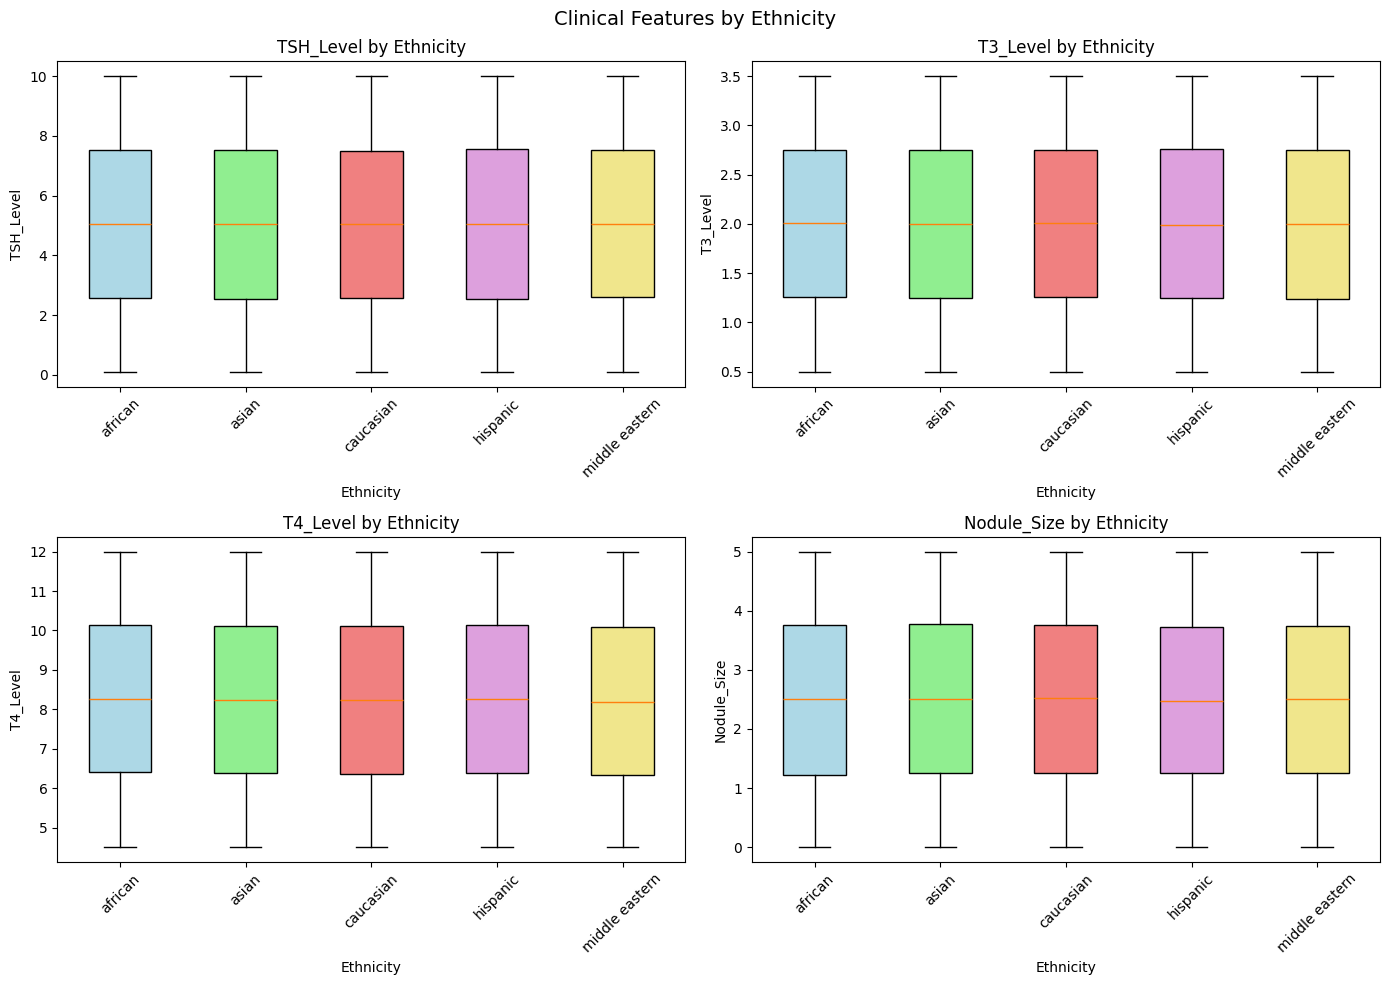

In [111]:
clinical_features = ["TSH_Level", "T3_Level", "T4_Level", "Nodule_Size"]
ethnicity_feature_summary = df_copy.groupby(ETHNICITY_COL)[clinical_features].agg(["mean", "median", "std"])
print(ethnicity_feature_summary)

figure, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

ethnicity_order = ["african", "asian", "caucasian", "hispanic", "middle eastern"]
box_colours = ["lightblue", "lightgreen", "lightcoral", "plum", "khaki"]

for index, feature_name in enumerate(clinical_features):
    grouped_values = [
        df_copy[df_copy[ETHNICITY_COL] == ethnicity_name][feature_name]
        for ethnicity_name in ethnicity_order
    ]
    
    boxplot = axes[index].boxplot(
        grouped_values,
        tick_labels=ethnicity_order,
        patch_artist=True
    )
    
    for box, colour in zip(boxplot["boxes"], box_colours):
        box.set_facecolor(colour)

    axes[index].set_title(f"{feature_name} by Ethnicity")
    axes[index].set_xlabel("Ethnicity")
    axes[index].set_ylabel(feature_name)
    axes[index].tick_params(axis="x", rotation=45)

figure.suptitle("Clinical Features by Ethnicity", fontsize=14)
plt.tight_layout()
plt.show()

### Comparison of Clinical Features Across Ethnic Groups

To investigate whether the observed differences in malignant diagnosis prevalence might be associated with underlying variation in clinical features, boxplots were produced for TSH level, T3 level, T4 level, and nodule size across ethnic groups.

The boxplots support the descriptive summary statistics, indicating that the distributions of these variables are broadly similar across ethnic groups. Although small differences and outliers are present, the overall central tendency and spread appear relatively consistent. Mean and median values for TSH, T3, T4, and nodule size showed only minor variation, and the standard deviations were also broadly similar between groups.

This suggests that the substantial differences in malignant diagnosis prevalence across ethnicity are not clearly explained by large differences in these average clinical measurements alone. From a fairness perspective, this is important because a predictive model may learn subgroup-dependent associations that are not immediately explained by simple feature averages. This strengthens the case for further model-based fairness evaluation focused on ethnicity.

# Baseline Models

In [112]:
feature_data_frame = df_copy.drop(columns=["Diagnosis", "target", "Thyroid_Cancer_Risk"])
target_series = df_copy["target"]

print("Feature shape:", feature_data_frame.shape)
print("Target shape:", target_series.shape)
print("\nFeature columns:")
print(feature_data_frame.columns.tolist())

Feature shape: (212691, 15)
Target shape: (212691,)

Feature columns:
['Age', 'Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size', 'Age_Group']


In [113]:
# Simple stratified split
X_train, X_test, y_train, y_test = train_test_split(
    feature_data_frame,
    target_series,
    test_size=0.25,
    stratify=target_series,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest target proportions:")
print(y_test.value_counts(normalize=True))

Training set shape: (159518, 15)
Test set shape: (53173, 15)

Training target proportions:
target
0    0.767293
1    0.232707
Name: proportion, dtype: float64

Test target proportions:
target
0    0.767288
1    0.232712
Name: proportion, dtype: float64


In [114]:
categorical_columns = X_train.select_dtypes(include="object").columns.tolist()
numerical_columns = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'Age_Group']

Numerical columns:
['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']


/tmp/ipykernel_853044/1519376115.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include="object").columns.tolist()


In [115]:
# Pre-processing Pipeline
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

In [116]:
# Logistic Regression Pipeline
logistic_regression_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest Pipeline
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [117]:
logistic_regression_pipeline.fit(X_train, y_train)
print("Baseline Logistic Regression model trained successfully.")

random_forest_pipeline.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Baseline Logistic Regression model trained successfully.
Random Forest model trained successfully.


In [118]:
y_pred = logistic_regression_pipeline.predict(X_test)
y_pred_proba = logistic_regression_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf = random_forest_pipeline.predict(X_test)
y_pred_proba_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [119]:
print("Logistic Regression Performance")
print("---------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Random Forest Performance")
print()
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Logistic Regression Performance
---------------------------
Accuracy: 0.7796249976491828
Precision: 0.6954707985697258
Recall: 0.09431065136576693
F1 Score: 0.16609735269000853
ROC-AUC: 0.6679134712436521

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.99      0.87     40799
           1       0.70      0.09      0.17     12374

    accuracy                           0.78     53173
   macro avg       0.74      0.54      0.52     53173
weighted avg       0.76      0.78      0.71     53173

Confusion Matrix:
[[40288   511]
 [11207  1167]]
Random Forest Performance

Accuracy: 0.8269798581987099
Precision: 0.7079947575360419
Recall: 0.43656053014385
F1 Score: 0.5400919816036792
ROC-AUC: 0.6977608857939019

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.89     40799
           1       0.71      0.44      0.54     12374

    accuracy                           

In [120]:
print("LR Results")
test_results = X_test.copy()
test_results["true_label"] = y_test.values
test_results["predicted_label"] = y_pred
test_results["predicted_probability"] = y_pred_proba
display(test_results.head())

print("RF Results")
rf_test_results = X_test.copy()
rf_test_results["true_label"] = y_test.values
rf_test_results["predicted_label"] = y_pred_rf
rf_test_results["predicted_probability"] = y_pred_proba_rf

display(rf_test_results.head())

LR Results


,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Age_Group,true_label,predicted_label,predicted_probability
161725,87,female,india,hispanic,yes,no,yes,no,yes,no,6.19,3.33,5.55,4.94,70+,1,0,0.437682
36064,45,male,usa,caucasian,no,no,no,no,yes,yes,0.87,2.95,10.38,1.66,40-49,0,0,0.094551
110091,28,male,china,caucasian,yes,no,yes,no,yes,no,1.20,1.42,8.43,1.50,0-29,1,0,0.288677
130249,70,male,uk,hispanic,no,no,yes,no,no,no,3.97,0.63,8.28,2.17,70+,1,0,0.162494
119621,67,male,india,asian,yes,no,no,no,no,no,4.65,2.60,11.90,1.48,60-69,1,1,0.529815


RF Results


,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Age_Group,true_label,predicted_label,predicted_probability
161725,87,female,india,hispanic,yes,no,yes,no,yes,no,6.19,3.33,5.55,4.94,70+,1,1,0.57
36064,45,male,usa,caucasian,no,no,no,no,yes,yes,0.87,2.95,10.38,1.66,40-49,0,0,0.12
110091,28,male,china,caucasian,yes,no,yes,no,yes,no,1.20,1.42,8.43,1.50,0-29,1,0,0.13
130249,70,male,uk,hispanic,no,no,yes,no,no,no,3.97,0.63,8.28,2.17,70+,1,0,0.21
119621,67,male,india,asian,yes,no,no,no,no,no,4.65,2.60,11.90,1.48,60-69,1,1,0.66


In [121]:
print("LR Results")
ethnicity_performance_rows = []

for ethnicity_name in sorted(test_results[ETHNICITY_COL].unique()):
    ethnicity_subset = test_results[test_results[ETHNICITY_COL] == ethnicity_name]
    
    subgroup_true = ethnicity_subset["true_label"]
    subgroup_pred = ethnicity_subset["predicted_label"]
    subgroup_proba = ethnicity_subset["predicted_probability"]
    
    ethnicity_performance_rows.append({
        "Ethnicity": ethnicity_name,
        "Count": len(ethnicity_subset),
        "Accuracy": accuracy_score(subgroup_true, subgroup_pred),
        "Precision": precision_score(subgroup_true, subgroup_pred, zero_division=0),
        "Recall": recall_score(subgroup_true, subgroup_pred, zero_division=0),
        "F1_Score": f1_score(subgroup_true, subgroup_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(subgroup_true, subgroup_proba)
    })

ethnicity_performance_data_frame = pd.DataFrame(ethnicity_performance_rows)
display(ethnicity_performance_data_frame.sort_values(by="Recall", ascending=False))

print("RF Results")
rf_ethnicity_performance_rows = []

for ethnicity_name in sorted(rf_test_results[ETHNICITY_COL].unique()):
    ethnicity_subset = rf_test_results[rf_test_results[ETHNICITY_COL] == ethnicity_name]

    subgroup_true = ethnicity_subset["true_label"]
    subgroup_pred = ethnicity_subset["predicted_label"]
    subgroup_proba = ethnicity_subset["predicted_probability"]

    rf_ethnicity_performance_rows.append({
        "Ethnicity": ethnicity_name,
        "Count": len(ethnicity_subset),
        "Accuracy": accuracy_score(subgroup_true, subgroup_pred),
        "Precision": precision_score(subgroup_true, subgroup_pred, zero_division=0),
        "Recall": recall_score(subgroup_true, subgroup_pred, zero_division=0),
        "F1_Score": f1_score(subgroup_true, subgroup_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(subgroup_true, subgroup_proba)
    })

rf_ethnicity_performance_data_frame = pd.DataFrame(rf_ethnicity_performance_rows)
display(rf_ethnicity_performance_data_frame.sort_values(by="Recall", ascending=False))

LR Results


,Ethnicity,Count,Accuracy,Precision,Recall,F1_Score,ROC_AUC
1,asian,13351,0.703093,0.700988,0.191150,0.300388,0.753633
0,african,10721,0.757858,0.667539,0.093612,0.164198,0.639659
3,hispanic,8021,0.827328,0.884615,0.016370,0.032145,0.582455
4,middle eastern,5180,0.825097,0.866667,0.014177,0.027897,0.566112
2,caucasian,15900,0.819686,0.609756,0.008693,0.017141,0.563007


RF Results


,Ethnicity,Count,Accuracy,Precision,Recall,F1_Score,ROC_AUC
1,asian,13351,0.799041,0.707094,0.678347,0.692422,0.777274
0,african,10721,0.821845,0.703908,0.515786,0.595339,0.729752
4,middle eastern,5180,0.848069,0.755906,0.209378,0.327925,0.596353
3,hispanic,8021,0.845905,0.724138,0.194306,0.306397,0.596357
2,caucasian,15900,0.837484,0.699454,0.178025,0.283814,0.584841


In [122]:
print("LR Results")
false_negative_rows = []

for ethnicity_name in sorted(test_results[ETHNICITY_COL].unique()):
    ethnicity_subset = test_results[test_results[ETHNICITY_COL] == ethnicity_name]
    
    subgroup_true = ethnicity_subset["true_label"]
    subgroup_pred = ethnicity_subset["predicted_label"]
    
    confusion_values = confusion_matrix(subgroup_true, subgroup_pred, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = confusion_values.ravel()
    
    false_negative_rate = false_negative / (false_negative + true_positive) if (false_negative + true_positive) > 0 else 0.0
    
    false_negative_rows.append({
        "Ethnicity": ethnicity_name,
        "Count": len(ethnicity_subset),
        "False_Negatives": false_negative,
        "True_Positives": true_positive,
        "False_Negative_Rate": false_negative_rate
    })

false_negative_data_frame = pd.DataFrame(false_negative_rows)
display(false_negative_data_frame.sort_values(by="False_Negative_Rate", ascending=False))

print("RF Results")
rf_false_negative_rows = []

for ethnicity_name in sorted(rf_test_results[ETHNICITY_COL].unique()):
    ethnicity_subset = rf_test_results[rf_test_results[ETHNICITY_COL] == ethnicity_name]

    subgroup_true = ethnicity_subset["true_label"]
    subgroup_pred = ethnicity_subset["predicted_label"]

    confusion_values = confusion_matrix(subgroup_true, subgroup_pred, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = confusion_values.ravel()

    false_negative_rate = (
        false_negative / (false_negative + true_positive)
        if (false_negative + true_positive) > 0 else 0.0
    )

    rf_false_negative_rows.append({
        "Ethnicity": ethnicity_name,
        "Count": len(ethnicity_subset),
        "False_Negatives": false_negative,
        "True_Positives": true_positive,
        "False_Negative_Rate": false_negative_rate
    })

rf_false_negative_data_frame = pd.DataFrame(rf_false_negative_rows)
display(rf_false_negative_data_frame.sort_values(by="False_Negative_Rate", ascending=False))

LR Results


,Ethnicity,Count,False_Negatives,True_Positives,False_Negative_Rate
2,caucasian,15900,2851,25,0.991307
4,middle eastern,5180,904,13,0.985823
3,hispanic,8021,1382,23,0.983630
0,african,10721,2469,255,0.906388
1,asian,13351,3601,851,0.808850


RF Results


,Ethnicity,Count,False_Negatives,True_Positives,False_Negative_Rate
2,caucasian,15900,2364,512,0.821975
3,hispanic,8021,1132,273,0.805694
4,middle eastern,5180,725,192,0.790622
0,african,10721,1319,1405,0.484214
1,asian,13351,1432,3020,0.321653


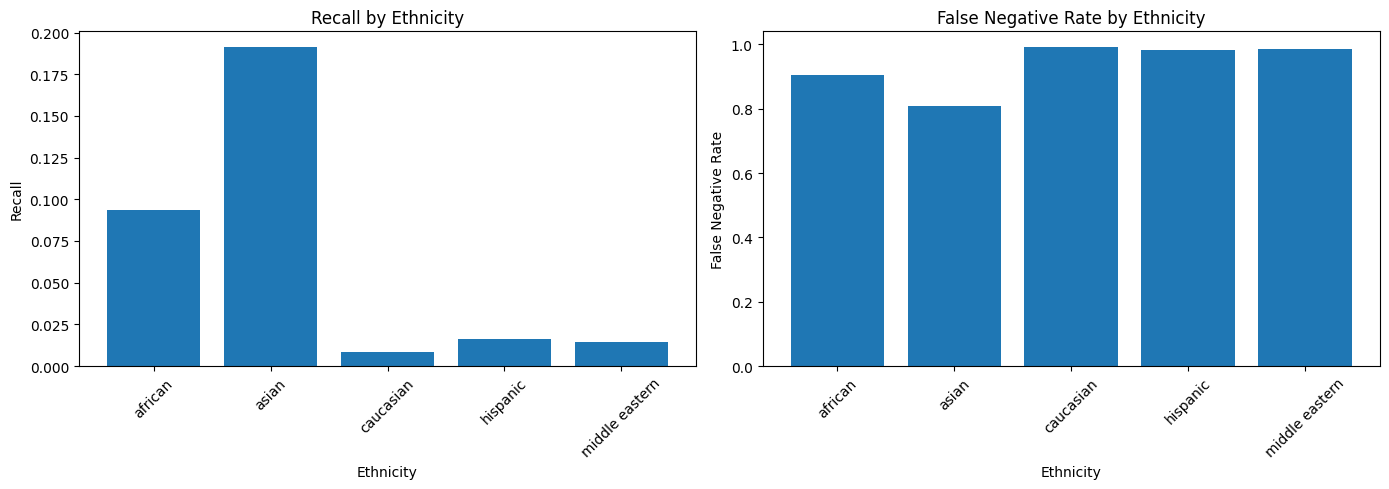

In [123]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    ethnicity_performance_data_frame["Ethnicity"],
    ethnicity_performance_data_frame["Recall"]
)
axes[0].set_title("Recall by Ethnicity")
axes[0].set_xlabel("Ethnicity")
axes[0].set_ylabel("Recall")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(
    false_negative_data_frame["Ethnicity"],
    false_negative_data_frame["False_Negative_Rate"]
)
axes[1].set_title("False Negative Rate by Ethnicity")
axes[1].set_xlabel("Ethnicity")
axes[1].set_ylabel("False Negative Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [141]:
ethnicity_model_summary = ethnicity_performance_data_frame[
    ["Ethnicity", "Count", "Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]
].merge(
    false_negative_data_frame[["Ethnicity", "False_Negative_Rate"]],
    on="Ethnicity",
    how="left"
).rename(columns={
    "Accuracy": "LR_Accuracy",
    "Precision": "LR_Precision",
    "Recall": "LR_Recall",
    "F1_Score": "LR_F1_Score",
    "ROC_AUC": "LR_ROC_AUC",
    "False_Negative_Rate": "LR_False_Negative_Rate"
})

ethnicity_model_summary = ethnicity_model_summary.merge(
    balanced_ethnicity_performance_data_frame[
        ["Ethnicity", "Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]
    ].merge(
        balanced_false_negative_data_frame[["Ethnicity", "False_Negative_Rate"]],
        on="Ethnicity",
        how="left"
    ).rename(columns={
        "Accuracy": "Balanced_LR_Accuracy",
        "Precision": "Balanced_LR_Precision",
        "Recall": "Balanced_LR_Recall",
        "F1_Score": "Balanced_LR_F1_Score",
        "ROC_AUC": "Balanced_LR_ROC_AUC",
        "False_Negative_Rate": "Balanced_LR_False_Negative_Rate"
    }),
    on="Ethnicity",
    how="left"
)

ethnicity_model_summary = ethnicity_model_summary.merge(
    rf_ethnicity_performance_data_frame[
        ["Ethnicity", "Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]
    ].merge(
        rf_false_negative_data_frame[["Ethnicity", "False_Negative_Rate"]],
        on="Ethnicity",
        how="left"
    ).rename(columns={
        "Accuracy": "RF_Accuracy",
        "Precision": "RF_Precision",
        "Recall": "RF_Recall",
        "F1_Score": "RF_F1_Score",
        "ROC_AUC": "RF_ROC_AUC",
        "False_Negative_Rate": "RF_False_Negative_Rate"
    }),
    on="Ethnicity",
    how="left"
)

display(ethnicity_model_summary.sort_values(by="RF_Recall", ascending=False))

,Ethnicity,Count,LR_Accuracy,LR_Precision,LR_Recall,LR_F1_Score,LR_ROC_AUC,LR_False_Negative_Rate,Balanced_LR_Accuracy,Balanced_LR_Precision,Balanced_LR_Recall,Balanced_LR_F1_Score,Balanced_LR_ROC_AUC,Balanced_LR_False_Negative_Rate,RF_Accuracy,RF_Precision,RF_Recall,RF_F1_Score,RF_ROC_AUC,RF_False_Negative_Rate
1,asian,13351,0.703093,0.700988,0.191150,0.300388,0.753633,0.808850,0.581904,0.433654,0.829515,0.569556,0.736197,0.170485,0.799041,0.707094,0.678347,0.692422,0.777274,0.321653
0,african,10721,0.757858,0.667539,0.093612,0.164198,0.639659,0.906388,0.520940,0.319190,0.781571,0.453268,0.648843,0.218429,0.821845,0.703908,0.515786,0.595339,0.729752,0.484214
4,middle eastern,5180,0.825097,0.866667,0.014177,0.027897,0.566112,0.985823,0.729151,0.284956,0.351145,0.314607,0.568228,0.648855,0.848069,0.755906,0.209378,0.327925,0.596353,0.790622
3,hispanic,8021,0.827328,0.884615,0.016370,0.032145,0.582455,0.983630,0.725969,0.279600,0.358007,0.313983,0.582820,0.641993,0.845905,0.724138,0.194306,0.306397,0.596357,0.805694
2,caucasian,15900,0.819686,0.609756,0.008693,0.017141,0.563007,0.991307,0.721321,0.274703,0.329624,0.299668,0.564320,0.670376,0.837484,0.699454,0.178025,0.283814,0.584841,0.821975


### Baseline Model Fairness Evaluation by Ethnicity

The baseline logistic regression model was evaluated across ethnic subgroups to assess whether predictive performance differed for the selected protected characteristic. While subgroup accuracy values ranged from 0.70 to 0.83, these results were not reflected in the model’s ability to correctly identify malignant cases. Recall was low across all ethnic groups and varied substantially, from 0.191 for the Asian subgroup to just 0.009 for the Caucasian subgroup.

This indicates that the model fails to identify a large proportion of malignant cases, and that this failure is not evenly distributed across ethnicity. The corresponding false negative rates were extremely high, ranging from 0.809 for the Asian subgroup to 0.991 for the Caucasian subgroup. In practical terms, this means that many malignant cases are incorrectly predicted as benign, with some ethnic groups affected more severely than others.

From a fairness perspective, these findings suggest that the baseline model does not satisfy an equal opportunity style interpretation of fairness, since recall differs markedly across ethnic groups. Furthermore, the results illustrate why accuracy alone is insufficient in a medical classification setting. Although the model achieves relatively high accuracy in some groups, this appears to be driven largely by correct classification of the majority class rather than reliable identification of malignant outcomes.

These findings raise important ethical concerns. In a clinical setting, false negatives may delay diagnosis and treatment, potentially causing disproportionate harm to certain demographic groups. Therefore, ethnicity remains an important focus for subsequent fairness mitigation and model refinement.

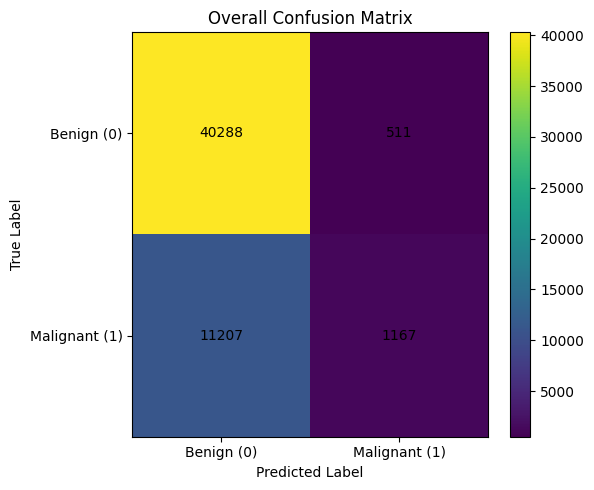

In [125]:
overall_confusion_matrix = confusion_matrix(y_test, y_pred)

figure, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(overall_confusion_matrix, aspect="auto")
plt.colorbar(image, ax=axis)

axis.set_title("Overall Confusion Matrix")
axis.set_xlabel("Predicted Label")
axis.set_ylabel("True Label")
axis.set_xticks([0, 1])
axis.set_yticks([0, 1])
axis.set_xticklabels(["Benign (0)", "Malignant (1)"])
axis.set_yticklabels(["Benign (0)", "Malignant (1)"])

for row_index in range(overall_confusion_matrix.shape[0]):
    for column_index in range(overall_confusion_matrix.shape[1]):
        axis.text(
            column_index,
            row_index,
            f"{overall_confusion_matrix[row_index, column_index]}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

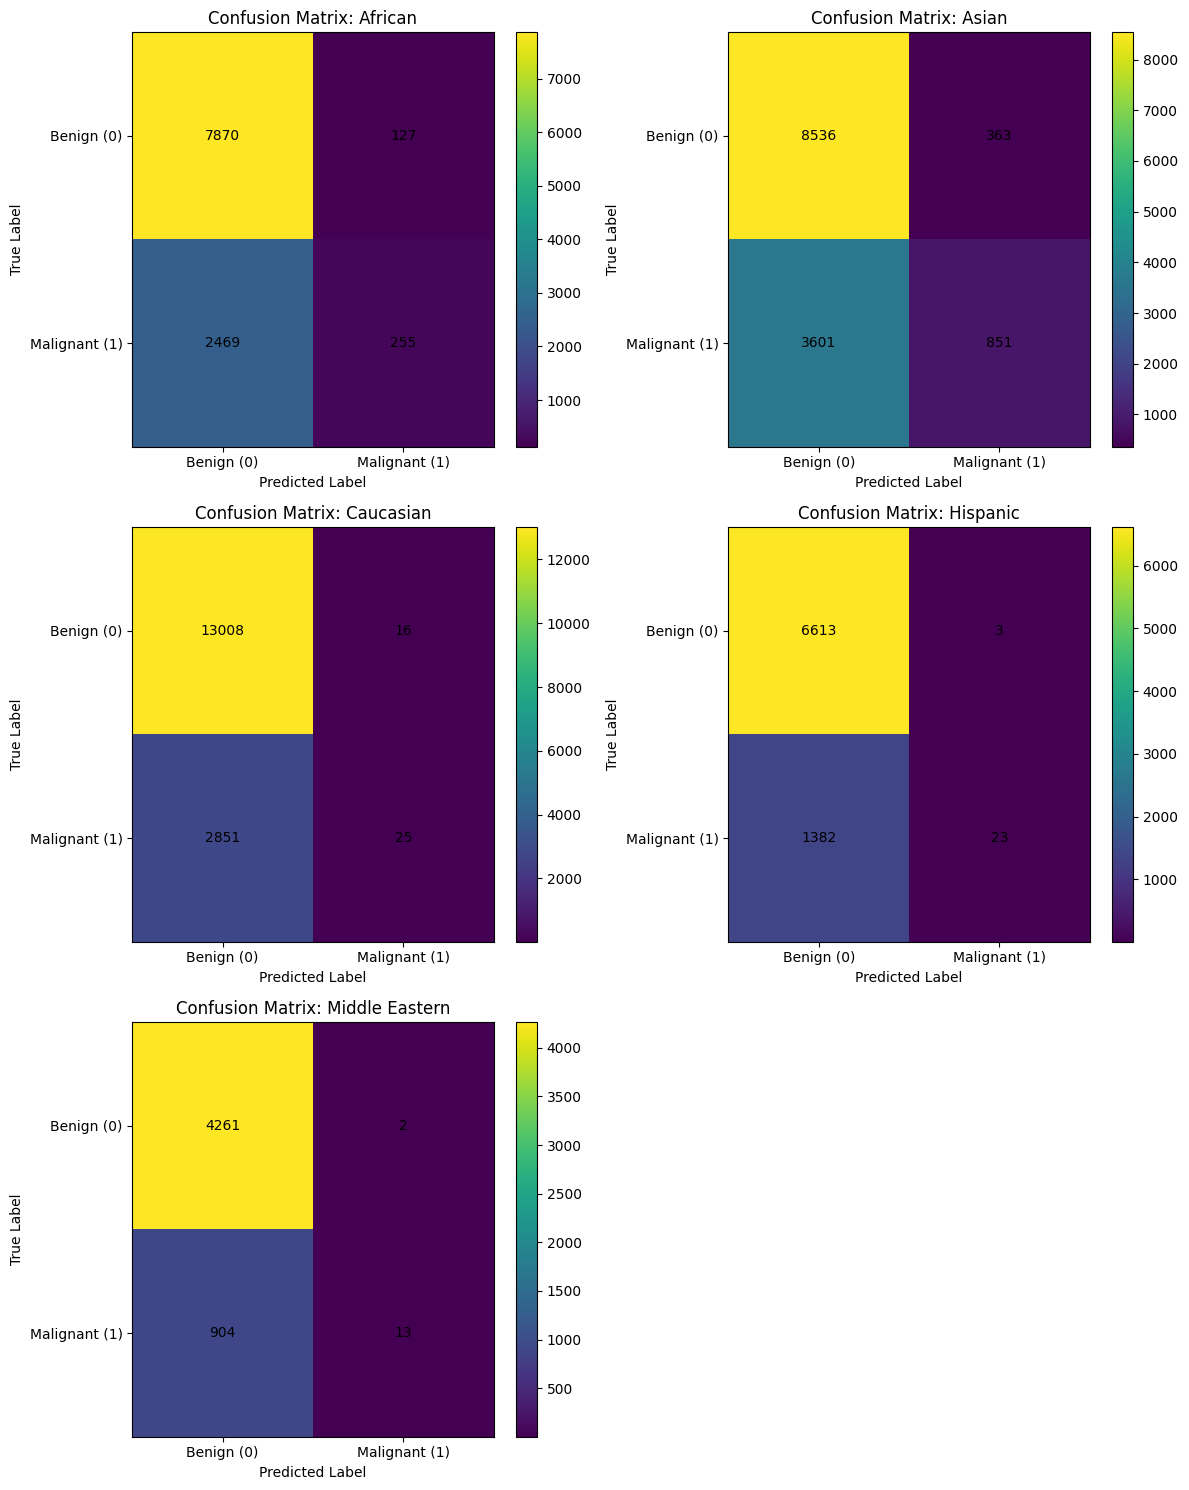

In [126]:
ethnicity_order = sorted(test_results[ETHNICITY_COL].unique())

figure, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for index, ethnicity_name in enumerate(ethnicity_order):
    ethnicity_subset = test_results[test_results[ETHNICITY_COL] == ethnicity_name]

    subgroup_true = ethnicity_subset["true_label"]
    subgroup_pred = ethnicity_subset["predicted_label"]

    subgroup_confusion_matrix = confusion_matrix(subgroup_true, subgroup_pred, labels=[0, 1])

    axis = axes[index]
    image = axis.imshow(subgroup_confusion_matrix, aspect="auto")
    figure.colorbar(image, ax=axis)

    axis.set_title(f"Confusion Matrix: {ethnicity_name.title()}")
    axis.set_xlabel("Predicted Label")
    axis.set_ylabel("True Label")
    axis.set_xticks([0, 1])
    axis.set_yticks([0, 1])
    axis.set_xticklabels(["Benign (0)", "Malignant (1)"])
    axis.set_yticklabels(["Benign (0)", "Malignant (1)"])

    for row_index in range(subgroup_confusion_matrix.shape[0]):
        for column_index in range(subgroup_confusion_matrix.shape[1]):
            axis.text(
                column_index,
                row_index,
                f"{subgroup_confusion_matrix[row_index, column_index]}",
                ha="center",
                va="center"
            )

# Turn off any unused subplot axes
for index in range(len(ethnicity_order), len(axes)):
    axes[index].axis("off")

plt.tight_layout()
plt.show()

# Balanced Model

In [127]:
balanced_logistic_regression_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

balanced_random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])


In [128]:
balanced_random_forest_pipeline.fit(X_train, y_train)
print("Balanced Random Forest model trained successfully.")

y_pred_balanced_rf = balanced_random_forest_pipeline.predict(X_test)
y_pred_proba_balanced_rf = balanced_random_forest_pipeline.predict_proba(X_test)[:, 1]

Balanced Random Forest model trained successfully.


In [129]:
balanced_logistic_regression_pipeline.fit(X_train, y_train)
print("Balanced Logistic Regression model trained successfully.")

y_pred_balanced_rf = balanced_random_forest_pipeline.predict(X_test)
y_pred_proba_balanced_rf = balanced_random_forest_pipeline.predict_proba(X_test)[:, 1]

Balanced Logistic Regression model trained successfully.


In [130]:
y_pred_balanced = balanced_logistic_regression_pipeline.predict(X_test)
y_pred_proba_balanced = balanced_logistic_regression_pipeline.predict_proba(X_test)[:, 1]

In [131]:
print("Balanced Logistic Regression Performance")
print()
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1 Score:", f1_score(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("Balanced Random Forest Performance")
print()
print("Accuracy:", accuracy_score(y_test, y_pred_balanced_rf))
print("Precision:", precision_score(y_test, y_pred_balanced_rf))
print("Recall:", recall_score(y_test, y_pred_balanced_rf))
print("F1 Score:", f1_score(y_test, y_pred_balanced_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_balanced_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced_rf))

Balanced Logistic Regression Performance

Accuracy: 0.6473774283941098
Precision: 0.35217471946582585
Recall: 0.6137869726846614
F1 Score: 0.44755450795521506
ROC-AUC: 0.6677459907413581

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.66      0.74     40799
           1       0.35      0.61      0.45     12374

    accuracy                           0.65     53173
   macro avg       0.60      0.64      0.59     53173
weighted avg       0.73      0.65      0.67     53173

Confusion Matrix:
[[26828 13971]
 [ 4779  7595]]
Balanced Random Forest Performance

Accuracy: 0.8254001090779155
Precision: 0.7072156652360515
Recall: 0.42613544528850816
F1 Score: 0.5318204740292486
ROC-AUC: 0.6970780776979668

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89     40799
           1       0.71      0.43      0.53     12374

    accuracy                           0.83  

In [142]:
print("LR Results")
balanced_test_results = X_test.copy()
balanced_test_results["true_label"] = y_test.values
balanced_test_results["predicted_label"] = y_pred_balanced
balanced_test_results["predicted_probability"] = y_pred_proba_balanced
display(balanced_test_results.head())

print("RF Results")
balanced_rf_test_results = X_test.copy()
balanced_rf_test_results["true_label"] = y_test.values
balanced_rf_test_results["predicted_label"] = y_pred_balanced_rf
balanced_rf_test_results["predicted_probability"] = y_pred_proba_balanced_rf

display(balanced_rf_test_results.head())

LR Results


,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Age_Group,true_label,predicted_label,predicted_probability
161725,87,female,india,hispanic,yes,no,yes,no,yes,no,6.19,3.33,5.55,4.94,70+,1,1,0.702806
36064,45,male,usa,caucasian,no,no,no,no,yes,yes,0.87,2.95,10.38,1.66,40-49,0,0,0.268276
110091,28,male,china,caucasian,yes,no,yes,no,yes,no,1.20,1.42,8.43,1.50,0-29,1,1,0.563243
130249,70,male,uk,hispanic,no,no,yes,no,no,no,3.97,0.63,8.28,2.17,70+,1,0,0.398350
119621,67,male,india,asian,yes,no,no,no,no,no,4.65,2.60,11.90,1.48,60-69,1,1,0.770069


RF Results


,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Age_Group,true_label,predicted_label,predicted_probability
161725,87,female,india,hispanic,yes,no,yes,no,yes,no,6.19,3.33,5.55,4.94,70+,1,1,0.540
36064,45,male,usa,caucasian,no,no,no,no,yes,yes,0.87,2.95,10.38,1.66,40-49,0,0,0.130
110091,28,male,china,caucasian,yes,no,yes,no,yes,no,1.20,1.42,8.43,1.50,0-29,1,0,0.130
130249,70,male,uk,hispanic,no,no,yes,no,no,no,3.97,0.63,8.28,2.17,70+,1,0,0.225
119621,67,male,india,asian,yes,no,no,no,no,no,4.65,2.60,11.90,1.48,60-69,1,1,0.680


In [143]:
print("LR Results")

balanced_ethnicity_performance_rows = []

for ethnicity_name in sorted(balanced_test_results[ETHNICITY_COL].unique()):
    ethnicity_subset = balanced_test_results[balanced_test_results[ETHNICITY_COL] == ethnicity_name]

    subgroup_true = ethnicity_subset["true_label"]
    subgroup_pred = ethnicity_subset["predicted_label"]
    subgroup_proba = ethnicity_subset["predicted_probability"]

    balanced_ethnicity_performance_rows.append({
        "Ethnicity": ethnicity_name,
        "Count": len(ethnicity_subset),
        "Accuracy": accuracy_score(subgroup_true, subgroup_pred),
        "Precision": precision_score(subgroup_true, subgroup_pred, zero_division=0),
        "Recall": recall_score(subgroup_true, subgroup_pred, zero_division=0),
        "F1_Score": f1_score(subgroup_true, subgroup_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(subgroup_true, subgroup_proba)
    })

balanced_ethnicity_performance_data_frame = pd.DataFrame(balanced_ethnicity_performance_rows)
display(balanced_ethnicity_performance_data_frame.sort_values(by="Recall", ascending=False))

print("RF Results")
balanced_rf_ethnicity_performance_rows = []

for ethnicity_name in sorted(balanced_rf_test_results[ETHNICITY_COL].unique()):
    ethnicity_subset = balanced_rf_test_results[balanced_rf_test_results[ETHNICITY_COL] == ethnicity_name]

    subgroup_true = ethnicity_subset["true_label"]
    subgroup_pred = ethnicity_subset["predicted_label"]
    subgroup_proba = ethnicity_subset["predicted_probability"]

    balanced_rf_ethnicity_performance_rows.append({
        "Ethnicity": ethnicity_name,
        "Count": len(ethnicity_subset),
        "Accuracy": accuracy_score(subgroup_true, subgroup_pred),
        "Precision": precision_score(subgroup_true, subgroup_pred, zero_division=0),
        "Recall": recall_score(subgroup_true, subgroup_pred, zero_division=0),
        "F1_Score": f1_score(subgroup_true, subgroup_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(subgroup_true, subgroup_proba)
    })

balanced_rf_ethnicity_performance_data_frame = pd.DataFrame(balanced_rf_ethnicity_performance_rows)
display(balanced_rf_ethnicity_performance_data_frame.sort_values(by="Recall", ascending=False))

LR Results


,Ethnicity,Count,Accuracy,Precision,Recall,F1_Score,ROC_AUC
1,asian,13351,0.581904,0.433654,0.829515,0.569556,0.736197
0,african,10721,0.520940,0.319190,0.781571,0.453268,0.648843
3,hispanic,8021,0.725969,0.279600,0.358007,0.313983,0.582820
4,middle eastern,5180,0.729151,0.284956,0.351145,0.314607,0.568228
2,caucasian,15900,0.721321,0.274703,0.329624,0.299668,0.564320


RF Results


,Ethnicity,Count,Accuracy,Precision,Recall,F1_Score,ROC_AUC
1,asian,13351,0.795446,0.705911,0.662624,0.683582,0.779258
0,african,10721,0.819700,0.704393,0.500367,0.585104,0.728601
4,middle eastern,5180,0.847490,0.755020,0.205016,0.322470,0.600296
3,hispanic,8021,0.845281,0.724044,0.188612,0.299266,0.591041
2,caucasian,15900,0.837170,0.697387,0.176287,0.281432,0.580540


In [144]:
print("LR Results")
balanced_false_negative_rows = []

for ethnicity_name in sorted(balanced_test_results[ETHNICITY_COL].unique()):
    ethnicity_subset = balanced_test_results[balanced_test_results[ETHNICITY_COL] == ethnicity_name]

    subgroup_true = ethnicity_subset["true_label"]
    subgroup_pred = ethnicity_subset["predicted_label"]

    confusion_values = confusion_matrix(subgroup_true, subgroup_pred, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = confusion_values.ravel()

    false_negative_rate = (
        false_negative / (false_negative + true_positive)
        if (false_negative + true_positive) > 0 else 0.0
    )

    balanced_false_negative_rows.append({
        "Ethnicity": ethnicity_name,
        "Count": len(ethnicity_subset),
        "False_Negatives": false_negative,
        "True_Positives": true_positive,
        "False_Negative_Rate": false_negative_rate
    })

balanced_false_negative_data_frame = pd.DataFrame(balanced_false_negative_rows)
display(balanced_false_negative_data_frame.sort_values(by="False_Negative_Rate", ascending=False))

print("RF Results")
balanced_rf_false_negative_rows = []

for ethnicity_name in sorted(balanced_rf_test_results[ETHNICITY_COL].unique()):
    ethnicity_subset = balanced_rf_test_results[balanced_rf_test_results[ETHNICITY_COL] == ethnicity_name]

    subgroup_true = ethnicity_subset["true_label"]
    subgroup_pred = ethnicity_subset["predicted_label"]

    confusion_values = confusion_matrix(subgroup_true, subgroup_pred, labels=[0, 1])
    true_negative, false_positive, false_negative, true_positive = confusion_values.ravel()

    false_negative_rate = (
        false_negative / (false_negative + true_positive)
        if (false_negative + true_positive) > 0 else 0.0
    )

    balanced_rf_false_negative_rows.append({
        "Ethnicity": ethnicity_name,
        "Count": len(ethnicity_subset),
        "False_Negatives": false_negative,
        "True_Positives": true_positive,
        "False_Negative_Rate": false_negative_rate
    })

balanced_rf_false_negative_data_frame = pd.DataFrame(balanced_rf_false_negative_rows)
display(balanced_rf_false_negative_data_frame.sort_values(by="False_Negative_Rate", ascending=False))

LR Results


,Ethnicity,Count,False_Negatives,True_Positives,False_Negative_Rate
2,caucasian,15900,1928,948,0.670376
4,middle eastern,5180,595,322,0.648855
3,hispanic,8021,902,503,0.641993
0,african,10721,595,2129,0.218429
1,asian,13351,759,3693,0.170485


RF Results


,Ethnicity,Count,False_Negatives,True_Positives,False_Negative_Rate
2,caucasian,15900,2369,507,0.823713
3,hispanic,8021,1140,265,0.811388
4,middle eastern,5180,729,188,0.794984
0,african,10721,1361,1363,0.499633
1,asian,13351,1502,2950,0.337376


In [145]:
baseline_recall = ethnicity_performance_data_frame[["Ethnicity", "Recall"]].rename(
    columns={"Recall": "Baseline_Recall"}
)

balanced_recall = balanced_ethnicity_performance_data_frame[["Ethnicity", "Recall"]].rename(
    columns={"Recall": "Balanced_Recall"}
)

baseline_fnr = false_negative_data_frame[["Ethnicity", "False_Negative_Rate"]].rename(
    columns={"False_Negative_Rate": "Baseline_False_Negative_Rate"}
)

balanced_fnr = balanced_false_negative_data_frame[["Ethnicity", "False_Negative_Rate"]].rename(
    columns={"False_Negative_Rate": "Balanced_False_Negative_Rate"}
)

ethnicity_model_comparison = baseline_recall.merge(balanced_recall, on="Ethnicity")
ethnicity_model_comparison = ethnicity_model_comparison.merge(baseline_fnr, on="Ethnicity")
ethnicity_model_comparison = ethnicity_model_comparison.merge(balanced_fnr, on="Ethnicity")

display(ethnicity_model_comparison)


,Ethnicity,Baseline_Recall,Balanced_Recall,Baseline_False_Negative_Rate,Balanced_False_Negative_Rate
0,african,0.093612,0.781571,0.906388,0.218429
1,asian,0.191150,0.829515,0.808850,0.170485
2,caucasian,0.008693,0.329624,0.991307,0.670376
3,hispanic,0.016370,0.358007,0.983630,0.641993
4,middle eastern,0.014177,0.351145,0.985823,0.648855


### Comparison of Logistic Regression and Random Forest Models by Ethnicity

The comparison of the three evaluated models shows that model choice and class balancing both had a substantial effect on subgroup performance. The baseline logistic regression model produced the weakest results, with an overall recall of 0.094 and extremely high false negative rates across all ethnic groups. Although its overall accuracy was 0.780, this performance was misleading in a medical context because the model failed to identify most malignant cases.

Applying class weighting to logistic regression substantially improved recall and reduced false negative rates across all ethnic groups. The balanced logistic regression model achieved an overall recall of 0.614, representing a major improvement in sensitivity to malignant cases. This was particularly important from an ethical perspective, as missed malignant diagnoses are likely to be more harmful than additional false positives. However, these gains came at the cost of lower overall accuracy, which fell to 0.647.

The standard random forest model provided the strongest overall performance balance, with an accuracy of 0.827, recall of 0.437, and F1-score of 0.540. It performed considerably better than baseline logistic regression and achieved a more balanced trade-off between sensitivity and overall predictive performance. Nevertheless, subgroup differences remained evident. For example, recall was substantially higher for the Asian subgroup than for the Caucasian, Hispanic, and Middle Eastern subgroups. This indicates that improving overall model performance does not necessarily remove fairness disparities.

Taken together, these findings suggest that class balancing is highly beneficial for reducing clinically harmful false negatives, while random forest provides stronger overall predictive performance. However, neither strategy fully eliminates ethnicity-based differences in model behaviour. This highlights the importance of evaluating both predictive performance and subgroup fairness when developing machine learning systems for healthcare.

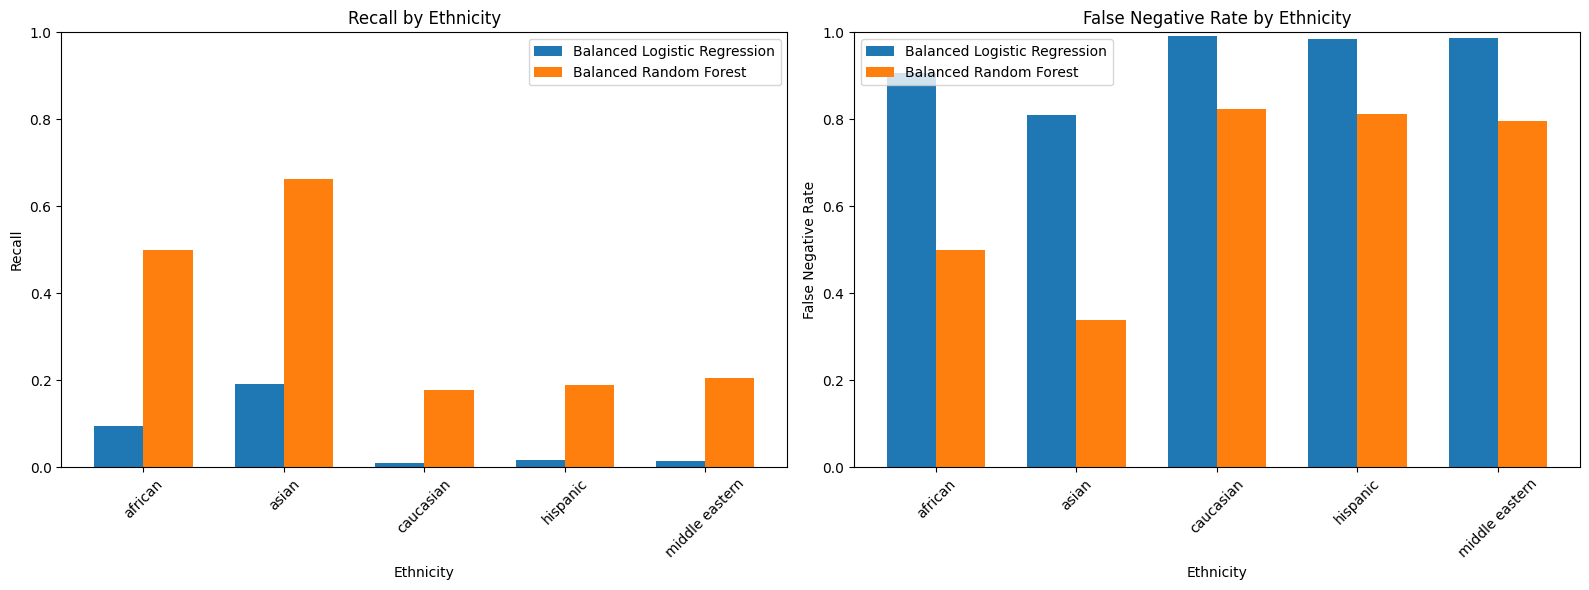

In [146]:
comparison_ethnicity_order = ["african", "asian", "caucasian", "hispanic", "middle eastern"]

lr_recall_plot = (
    ethnicity_performance_data_frame.set_index("Ethnicity")
    .reindex(comparison_ethnicity_order)["Recall"]
)

rf_recall_plot = (
    balanced_rf_ethnicity_performance_data_frame.set_index("Ethnicity")
    .reindex(comparison_ethnicity_order)["Recall"]
)

lr_fnr_plot = (
    false_negative_data_frame.set_index("Ethnicity")
    .reindex(comparison_ethnicity_order)["False_Negative_Rate"]
)

rf_fnr_plot = (
    balanced_rf_false_negative_data_frame.set_index("Ethnicity")
    .reindex(comparison_ethnicity_order)["False_Negative_Rate"]
)

x_positions = np.arange(len(comparison_ethnicity_order))
bar_width = 0.35

figure, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x_positions - bar_width / 2, lr_recall_plot, bar_width, label="Balanced Logistic Regression")
axes[0].bar(x_positions + bar_width / 2, rf_recall_plot, bar_width, label="Balanced Random Forest")
axes[0].set_title("Recall by Ethnicity")
axes[0].set_xlabel("Ethnicity")
axes[0].set_ylabel("Recall")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(comparison_ethnicity_order, rotation=45)
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(x_positions - bar_width / 2, lr_fnr_plot, bar_width, label="Balanced Logistic Regression")
axes[1].bar(x_positions + bar_width / 2, rf_fnr_plot, bar_width, label="Balanced Random Forest")
axes[1].set_title("False Negative Rate by Ethnicity")
axes[1].set_xlabel("Ethnicity")
axes[1].set_ylabel("False Negative Rate")
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(comparison_ethnicity_order, rotation=45)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

### TensorBoard and What-If Tool Setup Check

Before building predictive models, TensorBoard and the What-If Tool were tested to confirm that the environment was correctly configured for later experiment tracking and interactive model inspection.

In [136]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [137]:
log_dir = os.path.join(
    "/workspace/ethics_of_ai/logs/fit",
    datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

os.makedirs(log_dir, exist_ok=True)
print(log_dir)

/workspace/ethics_of_ai/logs/fit/20260425-121026


In [138]:
writer = tf.summary.create_file_writer(log_dir)

with writer.as_default():
    for step in range(5):
        tf.summary.scalar("test_metric", step * 0.1, step=step)

print("Test TensorBoard logs written.")

Test TensorBoard logs written.


In [139]:
%tensorboard --logdir /workspace/ethics_of_ai/logs/fit

Reusing TensorBoard on port 6007 (pid 853150), started 15:29:23 ago. (Use '!kill 853150' to kill it.)

In [140]:
from witwidget.notebook.visualization import WitWidget, WitConfigBuilder

print("What-If Tool imported successfully.")

ImportError: cannot import name 'display' from 'IPython.core.display' (/opt/venv/lib/python3.11/site-packages/IPython/core/display.py)